# **Part 8: Clustering [Phase 4]**

With customers now plotted on a 2D map in Part 7, Part 8 aims to draw boundaries around the dense regions, establishing the **tribes**. 2 methods are run and compared empirically to prove that HDBSCAN outperforms K-Means.

Methodology for Part 8:
1. Run HDBSCAN (primary) - density-based, no predefined K needed
2. Run K-Means (baseline) - spherical clusters, requires predefined K
3. Compare both methods quantitatively
4. Save tribe labels per customer

# ***To be deleted - for reference now***
### Step 8 — Clustering
**Phase:** Phase 4 | **Day 5**

**Why:** Now that customers are on a 2D map, we draw circles around the dense regions — those are the tribes. We use two methods and compare them to prove ours is better.

**Subtasks:**
- Run HDBSCAN on UMAP coordinates → automatically finds number of tribes, no K needed
- Run K-Means with K = the number HDBSCAN found → fair comparison baseline
- Measure both: silhouette score + Davies-Bouldin index
- Color-code the map by tribe label
- Extract top 10 most bought products per tribe

**Output:** `data/processed/customer_tribes.parquet` — tribe label per customer + colored cluster map


## 1. Imports and Setups
Standard libraries are loaded alongside `sklearn`'s built-in HDBSCAN and KMeans implementation and evaluation metrics such as Silhouette score, Davies-Bouldin index.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from pathlib import Path

import polars as pl

DATA_PROCESSED = Path("../data/processed")
print("Libraries loaded!")

Libraries loaded!


In [2]:
umap_df = pd.read_parquet(DATA_PROCESSED / "umap_coords.parquet")
coords = umap_df[["umap_x", "umap_y"]].values.astype(np.float32)

print(f"UMAP coords loaded: {coords.shape}")
print(umap_df.head(3))

UMAP coords loaded: (10000, 2)
                                             cliente    umap_x    umap_y
0  cb1b758af30dd2232afe64cbed4883becb91b6635afdbc... -3.716595  3.937875
1  d1d310341884089d6ac576f9af2a713497767cfdf7eb9d... -1.306668  7.913466
2  b73b40a57933850cc5d2780c8112a6ed0650d9fc62a5a4...  0.400414  3.305651


## 2. HDBSCAN (Primary method)
*HDBSCAN (Hierarchical Density-Based spatial Clustering of Applications with Noise) groups points purely by topological density. It organically discovers the number of tribes without needing a predefined K.*

**Why HDBSCAN is better for customer segmentation:**
- Customer tribes usually have irregular and non-spherical shapes which K-Means cannot capture
- HDBSCAN leaves anomalous customers unassigned (label = -1), instead of forcing them into the nearest tribe. This ensures that the profiles of each tribe remains clean
- Not required to establish K beforehand - the algorithm finds the natural number of tribes in the data

**Key parameters:**
- `min_cluster_size=50`: minimum number of customers to form a tribe
- `min_samples=10`: how conservative the clustering is; higher = fewer, more reliable tribes

**Output:** Tribe label per customer (-1 = noise/ outlier)

In [3]:
# HDBSCAN — using sklearn's implementation
print("Running HDBSCAN...")
clusterer = HDBSCAN(
    min_cluster_size=50,
    min_samples=10
)
hdb_labels = clusterer.fit_predict(coords)

n_tribes = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = (hdb_labels == -1).sum()

print(f"Tribes found: {n_tribes}")
print(f"Noise points: {n_noise} ({n_noise/len(hdb_labels)*100:.1f}%)")
print(f"Tribe sizes: {pd.Series(hdb_labels).value_counts().sort_index()}")

Running HDBSCAN...


/opt/anaconda3/envs/carrefour/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Tribes found: 74
Noise points: 1188 (11.9%)
Tribe sizes: -1     1188
 0       85
 1       66
 2      204
 3      278
       ... 
 69     195
 70      73
 71     105
 72     227
 73     133
Name: count, Length: 75, dtype: int64


## 3. K-Means (Baseline)
*K-Means partitions customers into K spherical clusters by minimising the distance from each point to its nearest centroid.*

K-Means method here serves as a baseline for a fair comparison, where K = number of tribes from HDBSCAN.

However, the fundamental limitations with K-Means include:
- Assumes all clusters are spherical which is not reflective of actual customer behaviour
- Forces every customer into a tribe and corrupts tribe profiles
- Requires establishing K upfront

In [4]:
# K-Means baseline — use same K as HDBSCAN found
print("Running K-Means...")
km = KMeans(n_clusters=n_tribes, random_state=42, n_init=10)
km_labels = km.fit_predict(coords)
print(f"K-Means done! K={n_tribes}")

Running K-Means...
K-Means done! K=74


2 metrics are used to evaluate the cluster quality:

**1. Silhouette Score (-1 to 1, higher = better)**
The Silhouette score measures how similar a customer is to their own tribe vs other tribes. A higher score indicates that the tribes are better separated.

**2. Davies-Bouldin Index (lower = better)**
The Davies-Bouldin Index measures the average similarity between each tribe and its most similar tribe. A lower score means tribes are compact and well-separated.

In [5]:
# Compare scores
# Filter out noise points (-1) for silhouette calculation
mask = hdb_labels != -1

hdb_sil = silhouette_score(coords[mask], hdb_labels[mask])
hdb_db = davies_bouldin_score(coords[mask], hdb_labels[mask])

km_sil = silhouette_score(coords, km_labels)
km_db = davies_bouldin_score(coords, km_labels)

print(f"{'Method':<12} {'Silhouette':>12} {'Davies-Bouldin':>15}")
print(f"{'-'*40}")
print(f"{'HDBSCAN':<12} {hdb_sil:>12.4f} {hdb_db:>15.4f}")
print(f"{'K-Means':<12} {km_sil:>12.4f} {km_db:>15.4f}")
print(f"\nWinner (silhouette): {'HDBSCAN' if hdb_sil > km_sil else 'K-Means'}")
print(f"Winner (Davies-Bouldin, lower=better): {'HDBSCAN' if hdb_db < km_db else 'K-Means'}")

Method         Silhouette  Davies-Bouldin
----------------------------------------
HDBSCAN            0.7420          0.3656
K-Means            0.6751          0.4582

Winner (silhouette): HDBSCAN
Winner (Davies-Bouldin, lower=better): HDBSCAN


## 4. Visualization of Clusters
Side-by-side scatter plots of HDBSCAN vs K-Means on the UMAP coordinates, colour-coded by tribe label

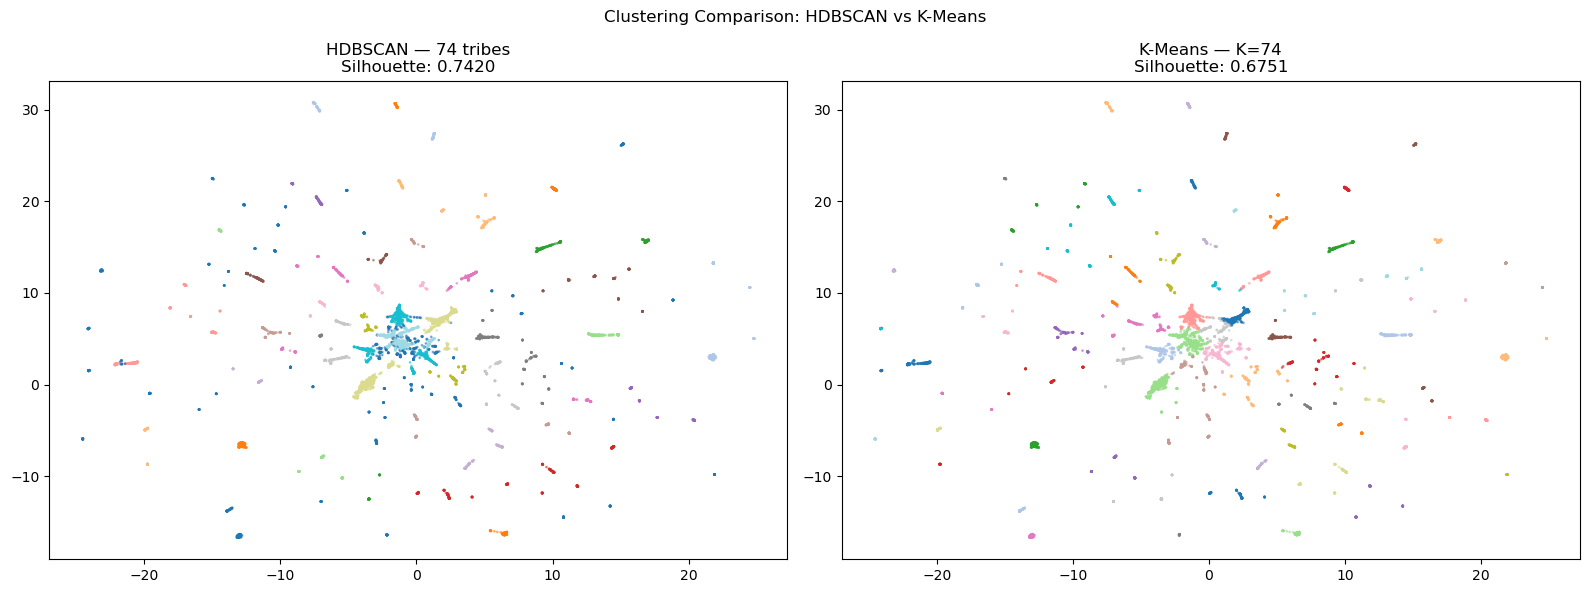

Plot saved!


In [6]:
# Colored cluster map
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# HDBSCAN plot
scatter1 = axes[0].scatter(
    coords[:, 0], coords[:, 1],
    c=hdb_labels, cmap="tab20", s=1, alpha=0.5
)
axes[0].set_title(f"HDBSCAN — {n_tribes} tribes\nSilhouette: {hdb_sil:.4f}")

# K-Means plot
scatter2 = axes[1].scatter(
    coords[:, 0], coords[:, 1],
    c=km_labels, cmap="tab20", s=1, alpha=0.5
)
axes[1].set_title(f"K-Means — K={n_tribes}\nSilhouette: {km_sil:.4f}")

plt.suptitle("Clustering Comparison: HDBSCAN vs K-Means")
plt.tight_layout()
plt.savefig("../outputs/clustering_comparison.png", dpi=150)
plt.show()
print("Plot saved!")

**Notes from clustering visualisations:**

**1. HDBSCAN**
- Finds clusters organically based on density
- Clusters follow the natural shape of the data, irregular and non-spherical
- Grey/ noise points (-1) are left unassigned - these are anomalous customers that do not fit any tribe

**2. K-Means**
- Forces every single point into a cluster - no noise, no outliers
- Clusters are roughly spherical because K-Means assumes circular shapes
- Artificially assigns anomalous customers to the nearest centroid even when they do not belong

## 5. Top 10 Products per Tribe
After establishing the clusters, we now look into what each tribe buys, by finding the top 10 most purchased products per tribe. This forms the basis for tribe naming and profilling in Part 9.

In [7]:
# Top 10 most bought products per tribe
df_combined = pl.scan_parquet(DATA_PROCESSED / "df_combined.parquet")
tribes = pd.read_parquet(DATA_PROCESSED / "customer_tribes.parquet")

# merge tribe labels back to transactions
print("Top products per tribe — run after full embeddings are available")
print(f"Tribes file shape: {tribes.shape}")
print(f"Columns: {tribes.columns.tolist()}")

Top products per tribe — run after full embeddings are available
Tribes file shape: (10000, 5)
Columns: ['cliente', 'umap_x', 'umap_y', 'tribe_hdbscan', 'tribe_kmeans']


In [8]:
# Save customer tribes
umap_df["tribe_hdbscan"] = hdb_labels
umap_df["tribe_kmeans"] = km_labels
umap_df.to_parquet(DATA_PROCESSED / "customer_tribes.parquet", index=False)

print(f"Saved customer_tribes.parquet")
print(f"Shape: {umap_df.shape}")
print(umap_df.head(3))

Saved customer_tribes.parquet
Shape: (10000, 5)
                                             cliente    umap_x    umap_y  \
0  cb1b758af30dd2232afe64cbed4883becb91b6635afdbc... -3.716595  3.937875   
1  d1d310341884089d6ac576f9af2a713497767cfdf7eb9d... -1.306668  7.913466   
2  b73b40a57933850cc5d2780c8112a6ed0650d9fc62a5a4...  0.400414  3.305651   

   tribe_hdbscan  tribe_kmeans  
0             67             5  
1             68            29  
2             69            49  


## Silvia add-on — stronger clustering outputs and interpretation

Rachel's notebook already compares HDBSCAN against K-Means using silhouette and Davies-Bouldin scores. The following additions make the clustering deliverables more complete for the final capstone:

- save a reusable metric comparison table;
- save the final customer-to-tribe assignment;
- create a tribe-size summary;
- extract top products per tribe after the tribe labels are available;
- add business interpretation for the HDBSCAN vs K-Means comparison.

In [ ]:
# Silvia add-on: save clustering metrics in a table
metrics_df = pd.DataFrame({
    "method": ["HDBSCAN", "K-Means"],
    "n_clusters_or_tribes": [n_tribes, n_tribes],
    "silhouette_score": [hdb_sil, km_sil],
    "davies_bouldin_index": [hdb_db, km_db],
    "noise_points": [int(n_noise), 0],
    "notes": [
        "Density-based method; can identify irregular groups and mark outliers/noise.",
        "Centroid-based baseline; forces every customer into a cluster."
    ]
})

metrics_path = DATA_PROCESSED / "clustering_metrics.parquet"
metrics_df.to_parquet(metrics_path, index=False)

print(metrics_df)
print(f"Saved clustering metrics to: {metrics_path}")

In [ ]:
# Silvia add-on: save tribe assignments before any downstream profiling
tribes_output = umap_df.copy()
tribes_output["tribe_hdbscan"] = hdb_labels
tribes_output["tribe_kmeans"] = km_labels

tribes_path = DATA_PROCESSED / "customer_tribes.parquet"
tribes_output.to_parquet(tribes_path, index=False)

tribe_size_summary = (
    tribes_output["tribe_hdbscan"]
    .value_counts()
    .rename_axis("tribe_hdbscan")
    .reset_index(name="n_customers")
    .sort_values("tribe_hdbscan")
)

tribe_size_summary["share_of_sample"] = tribe_size_summary["n_customers"] / len(tribes_output)
size_path = DATA_PROCESSED / "tribe_size_summary.parquet"
tribe_size_summary.to_parquet(size_path, index=False)

print(tribe_size_summary)
print(f"Saved tribe assignments to: {tribes_path}")
print(f"Saved tribe size summary to: {size_path}")

In [ ]:
# Silvia add-on: extract top products per HDBSCAN tribe
# This cell is written defensively because product-name columns may vary depending on the cleaned dataset.

transactions = (
    pl.scan_parquet(DATA_PROCESSED / "df_combined.parquet")
    .select(pl.all())
    .collect(engine="streaming")
    .to_pandas()
)

tribes_for_join = tribes_output[["cliente", "tribe_hdbscan"]].copy()

# Exclude noise customers from tribe profiling because -1 means no stable tribe was assigned.
tribes_for_join = tribes_for_join[tribes_for_join["tribe_hdbscan"] != -1]

tx_tribes = transactions.merge(tribes_for_join, on="cliente", how="inner")

# Try to identify product/category columns available in the dataset.
candidate_product_cols = [
    "idarticu", "descripcion", "desc_articulo", "nombre_articulo",
    "categoria", "seccion", "familia", "subfamilia"
]
available_product_cols = [c for c in candidate_product_cols if c in tx_tribes.columns]

if "unidades" in tx_tribes.columns:
    volume_col = "unidades"
else:
    volume_col = None

group_cols = ["tribe_hdbscan"] + available_product_cols

if len(available_product_cols) == 0:
    print("No product/category descriptor columns found. Available columns are:")
    print(tx_tribes.columns.tolist())
else:
    if volume_col:
        top_products = (
            tx_tribes.groupby(group_cols, dropna=False)[volume_col]
            .sum()
            .reset_index(name="total_units")
            .sort_values(["tribe_hdbscan", "total_units"], ascending=[True, False])
        )
    else:
        top_products = (
            tx_tribes.groupby(group_cols, dropna=False)
            .size()
            .reset_index(name="n_transactions")
            .sort_values(["tribe_hdbscan", "n_transactions"], ascending=[True, False])
        )

    top10_by_tribe = top_products.groupby("tribe_hdbscan").head(10)
    top_path = DATA_PROCESSED / "top10_products_by_tribe.parquet"
    top10_by_tribe.to_parquet(top_path, index=False)

    print(top10_by_tribe.head(30))
    print(f"Saved top 10 products per tribe to: {top_path}")

### Part 8 conclusion

HDBSCAN is the preferred clustering method for this project because it matches the business problem better than K-Means. Customer tribes are unlikely to be perfectly round or equally sized, and some customers may not belong clearly to any tribe. HDBSCAN can handle both situations because it identifies dense behavioural regions and assigns uncertain customers to noise.

K-Means is still useful as a baseline because it provides a simple comparison: it forces every customer into one of K groups. If HDBSCAN achieves a higher silhouette score and a lower Davies-Bouldin index, it supports the claim that density-based tribes are more coherent and better separated.

The final output, `customer_tribes.parquet`, is the key input for the next stage of the project: tribe profiling and naming. The top-products table helps translate numeric clusters into commercial segments that Carrefour can understand and activate.